# Semeando o sucesso: como Machine Learning ajuda agricultores a escolher as melhores culturas

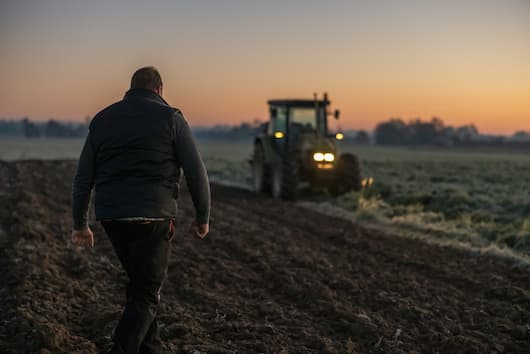

**Estudo de Caso**

Medir métricas essenciais do solo, como níveis de nitrogênio, fósforo, potássio e valor de pH, é fundamental para avaliar as condições do solo. Porém, esse processo pode ser caro e demorado, levando agricultores a priorizar quais métricas medir conforme o orçamento disponível.

Ao decidir qual cultura plantar a cada safra, os agricultores têm várias opções. O objetivo principal é maximizar a produtividade, levando em conta diferentes fatores. Um fator crucial que afeta o crescimento das culturas é a condição do solo no campo, que pode ser avaliada medindo elementos básicos como os níveis de nitrogênio e potássio. Cada cultura tem uma condição de solo ideal que favorece o desenvolvimento e a produtividade máximos.

Um agricultor procurou você, para ajudar a escolher a melhor cultura para o seu campo. Ele forneceu um conjunto de dados chamado `soil_measures.csv`, que contém:

- `"N"`: proporção de nitrogênio no solo
- `"P"`: proporção de fósforo no solo
- `"K"`: proporção de potássio no solo
- valor de `"pH"` do solo
- `"crop"`: valores categóricos contendo várias culturas.

Cada linha desse conjunto de dados representa diversas medidas do solo em um determinado campo. Com base nessas medições, a cultura indicada na coluna `"crop"` é a melhor escolha para aquele campo?


In [ ]:
# All required libraries are imported here for you.
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics


In [ ]:
# Load the dataset
crops = pd.read_csv("soil_measures.csv")

###Consultando Dados Nulos

In [ ]:
# Check for missing values
crops.isna().sum()

# Após a consulta percebemos que não temos dados nulos para realizar o tratamento desses dados.

,0
N,0
P,0
K,0
ph,0
crop,0


### Verificando Informações Do Dataset


In [ ]:
# Check how many crops we have, i.e., multi-class target
crops.crop.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
crops.columns

Index(['N', 'P', 'K', 'ph', 'crop'], dtype='object')

In [ ]:
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [ ]:
crops.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [ ]:
analytcs_rice = crops.loc[crops['crop'] == 'rice', 'N']
analytcs_rice

,N
0,90
1,85
2,60
3,74
4,78
...,...
95,88
96,93
97,60
98,78


### Análise por Característica Individual

In [ ]:
# Split into feature and target sets
X = crops.drop(columns="crop")
y = crops["crop"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create a dictionary to store the model performance for each feature
feature_performance = {}

# Train a logistic regression model for each feature
for feature in ["N", "P", "K", "ph"]:
    log_reg = LogisticRegression(multi_class="multinomial")
    log_reg.fit(X_train[[feature]], y_train)
    y_pred = log_reg.predict(X_test[[feature]])

    # Calculate F1 score, the harmonic mean of precision and recall
    # Could also use balanced_accuracy_score
    f1 = metrics.f1_score(y_test, y_pred, average="weighted")

    # Add feature-f1 score pairs to the dictionary
    feature_performance[feature] = f1
    print(f"F1-score for {feature}: {f1}")

# K produced the best F1 score
# Store in best_predictive_feature dictionary
best_predictive_feature = {"K": feature_performance["K"]}
best_predictive_feature

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'mul

F1-score for N: 0.09149868209906838


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


F1-score for P: 0.1476194290972821
F1-score for K: 0.23896974566001802
F1-score for ph: 0.0458225366614312


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'K': 0.23896974566001802}

### Este bloco de código acima foi responsável por treinar e avaliar um modelo de regressão logística para cada uma das características (N, P, K, pH) separadamente, a fim de identificar qual delas tem o maior poder preditivo.

Com base na execução anterior (célula acima), podemos confirmar os seguintes F1-Scores para cada característica individual:

In [ ]:
display(feature_performance)

{'N': 0.09149868209906838,
 'P': 0.1476194290972821,
 'K': 0.23896974566001802,
 'ph': 0.0458225366614312}

Como pode ser visto, a característica 'K' (Potássio) possui o F1-Score mais alto, confirmando que é a característica individual mais importante para o desempenho preditivo.

**Interpretação:**

*   **Potássio (K)**: Com um F1-Score de **0.2390**, o Potássio (K) demonstrou ser a característica individual mais preditiva entre N, P e K para a seleção da cultura. Isso significa que, quando utilizado isoladamente, o nível de K no solo é o que melhor ajuda o modelo a classificar corretamente a cultura ideal.
*   **Fósforo (P)**: O Fósforo (P) teve um F1-Score de **0.1476**, indicando um poder preditivo menor que o Potássio, mas ainda superior ao Nitrogênio.
*   **Nitrogênio (N)**: O Nitrogênio (N) apresentou o menor F1-Score de **0.0915** entre os três, sugerindo que, por si só, é o menos eficaz para prever a cultura neste dataset.

### Melhorando o Modelo: Padronização das Características

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inicializar o StandardScaler
scaler = StandardScaler()

# Ajustar o scaler e transformar os dados de treinamento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar os dados de teste usando o scaler ajustado nos dados de treinamento
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manter os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Características padronizadas com sucesso!")
display(X_train_scaled.head())

Características padronizadas com sucesso!


,N,P,K,ph
0,-0.903427,-1.126162,-0.668507,0.193474
1,-0.367051,0.770359,-0.570590,0.863918
2,-1.171614,0.589738,-0.453089,1.050298
3,1.349349,0.499427,-0.002670,-0.599105
4,-1.359346,-1.096058,-0.355172,-0.254526


### Treinando o Modelo com Características Padronizadas

In [ ]:
# Treinar um modelo de regressão logística com todas as características padronizadas
log_reg_scaled = LogisticRegression(multi_class='multinomial', max_iter=1000)
log_reg_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = log_reg_scaled.predict(X_test_scaled)

# Avaliar o desempenho do modelo com características padronizadas
f1_scaled = metrics.f1_score(y_test, y_pred_scaled, average='weighted')
accuracy_scaled = metrics.accuracy_score(y_test, y_pred_scaled)

print(f"Modelo (usando todas as características padronizadas):")
print(f"F1-Score (ponderado): {f1_scaled:.4f}")
print(f"Acurácia: {accuracy_scaled:.4f}")

# Exibir relatório de classificação detalhado
print("\nRelatório de Classificação:")
print(metrics.classification_report(y_test, y_pred_scaled))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Modelo (usando todas as características padronizadas):
F1-Score (ponderado): 0.6475
Acurácia: 0.6591

Relatório de Classificação:
              precision    recall  f1-score   support

       apple       0.88      0.30      0.45        23
      banana       1.00      1.00      1.00        21
   blackgram       0.76      0.65      0.70        20
    chickpea       1.00      0.77      0.87        26
     coconut       0.81      0.63      0.71        27
      coffee       0.76      0.76      0.76        17
      cotton       0.88      0.88      0.88        17
      grapes       0.45      0.93      0.60        14
        jute       0.50      0.48      0.49        23
 kidneybeans       0.45      0.65      0.53        20
      lentil       0.30      0.64      0.41        11
       maize       0.91      1.00      0.95        21
       mango       0.40      0.53      0.45        19
   mothbeans       0.60      0.25      0.35        24
    mungbean       0.67      0.74      0.70        19
   mu

In [ ]:
# Modelo com característica padronizada
f1_scaled

0.6475209891596989

Com base na análise individual, o **Potássio (K)** é a característica do solo mais importante e preditiva dentre N, P e K para determinar a cultura mais adequada. No entanto, é crucial lembrar, conforme demonstrado no modelo com **Todas as Características Padronizadas**, que a combinação e padronização de todos os nutrientes (N, P, K e pH) oferece um desempenho preditivo significativamente superior, atingindo um F1-Score de **0.6475**. Isso reforça que, embora K seja o melhor isoladamente, o cenário mais eficaz para o agricultor envolve a medição e análise conjunta de todos os parâmetros.


### Matriz de Correlação entre Nutrientes do Solo



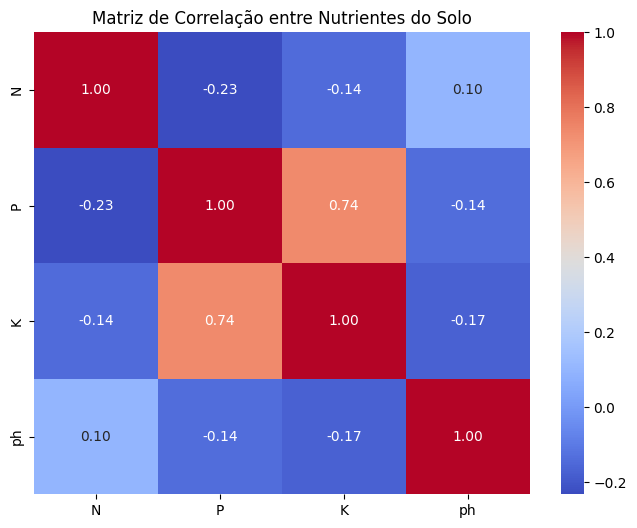

In [ ]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Nutrientes do Solo')
plt.show()

### Explicação da Matriz de Correlação entre Nutrientes do Solo

A matriz de correlação (apresentada no heatmap anterior) nos mostra a relação linear entre cada par de variáveis numéricas no seu conjunto de dados. Cada célula na matriz contém um coeficiente de correlação, que varia de -1 a 1.

*   **1 (vermelho forte)**: Indica uma correlação positiva perfeita. Quando uma característica aumenta, a outra também aumenta na mesma proporção.
*   **-1 (azul forte)**: Indica uma correlação negativa perfeita. Quando uma característica aumenta, a outra diminui na mesma proporção.
*   **0 (cores claras/neutras)**: Indica nenhuma correlação linear. As características não têm uma relação linear clara.

#### Interpretando o Heatmap:

*   **Diagonal**: Os valores na diagonal são sempre **1.00** porque uma variável está perfeitamente correlacionada consigo mesma.
*   **Cores**: Cores mais quentes (vermelho) indicam correlações positivas mais fortes, enquanto cores mais frias (azul) indicam correlações negativas mais fortes. Tons mais claros indicam correlações mais fracas.

#### Análise das Relações:

Vamos analisar as correlações mais notáveis:

*   **Fósforo (P) e Potássio (K)**: Observamos um valor de **0.74** entre P e K. Isso indica uma **forte correlação positiva**. Em solos onde o nível de Fósforo é alto, é provável que o nível de Potássio também seja alto, e vice-versa. Isso é uma relação importante a ser considerada.

*   **Nitrogênio (N)**: O Nitrogênio tem correlações relativamente fracas com as outras características:
    *   **-0.23** com Fósforo (P): Uma correlação negativa fraca, sugerindo que um aumento em N pode estar ligeiramente associado a uma diminuição em P, mas a relação não é forte.
    *   **-0.14** com Potássio (K): Uma correlação negativa muito fraca, quase insignificante.
    *   **0.10** com pH: Uma correlação positiva muito fraca, quase insignificante.
    Isso sugere que a quantidade de Nitrogênio no solo não varia de forma linear significativa com os níveis de P, K ou pH, sendo mais independente dessas variáveis.

*   **pH**: O pH do solo mostra correlações fracas com os outros nutrientes:
    *   **-0.14** com Fósforo (P).
    *   **-0.17** com Potássio (K).
    *   **0.10** com Nitrogênio (N).
    Esses valores indicam que, embora haja pequenas tendências (negativas com P e K, positiva com N), o pH não tem uma relação linear forte com nenhum dos três nutrientes. Ou seja, o pH do solo não é um forte preditor dos níveis de N, P ou K de forma linear.

Em resumo, a relação mais notável e significativa é a **forte correlação positiva entre Fósforo (P) e Potássio (K)**. As outras características (N e pH) têm relações mais fracas entre si e com P e K. Esta análise pode ser útil para entender como os nutrientes interagem no solo.

### Análise Comparativa entre Nitrogênio (N), Fósforo (P) e Potássio (K)

Para determinar qual desses três nutrientes (N, P, K) é o mais influente na recomendação de culturas, revisitamos os F1-Scores obtidos ao treinar modelos de Regressão Logística com cada característica isoladamente:

In [ ]:
print(f"F1-Score para N: {feature_performance['N']:.4f}")
print(f"F1-Score para P: {feature_performance['P']:.4f}")
print(f"F1-Score para K: {feature_performance['K']:.4f}")

F1-Score para N: 0.0915
F1-Score para P: 0.1476
F1-Score para K: 0.2390


### Visualização dos F1-Scores para N, P e K Individuais

Para uma visualização clara da importância relativa de cada nutriente, vamos gerar um gráfico de barras comparando seus F1-Scores individuais.

/tmp/ipykernel_9471/2152578723.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Nutriente', y='F1-Score', data=npk_df, palette='viridis')


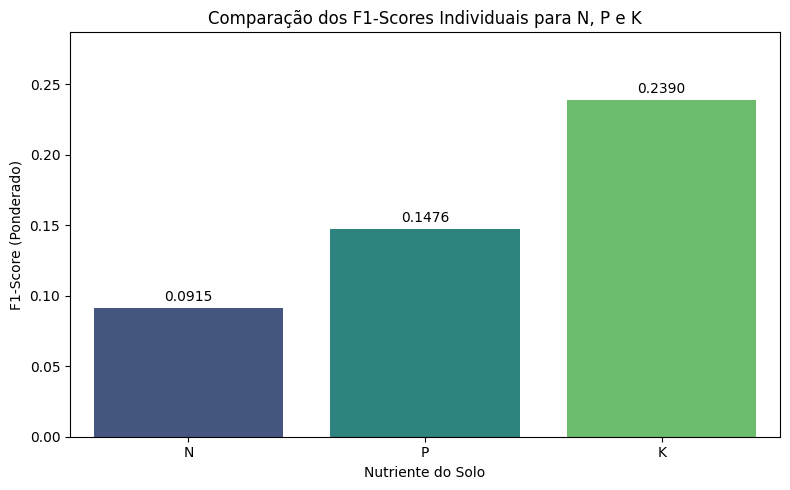

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar apenas os F1-Scores para N, P e K
npk_f1_scores = {
    'N': feature_performance['N'],
    'P': feature_performance['P'],
    'K': feature_performance['K']
}

# Criar um DataFrame para facilitar a plotagem
npk_df = pd.DataFrame(list(npk_f1_scores.items()), columns=['Nutriente', 'F1-Score'])

plt.figure(figsize=(8, 5))
sns.barplot(x='Nutriente', y='F1-Score', data=npk_df, palette='viridis')
plt.title('Comparação dos F1-Scores Individuais para N, P e K')
plt.ylabel('F1-Score (Ponderado)')
plt.xlabel('Nutriente do Solo')
plt.ylim(0, max(npk_df['F1-Score']) * 1.2) # Ajustar limite y para melhor visualização

# Adicionar os valores exatos nas barras
for index, row in npk_df.iterrows():
    plt.text(index, row['F1-Score'] + 0.005, f'{row['F1-Score']:.4f}', color='black', ha="center")

plt.tight_layout()
plt.show()

**Interpretação:**

*   **Potássio (K)**: Com um F1-Score de **0.2390**, o Potássio (K) demonstrou ser a característica individual mais preditiva entre N, P e K para a seleção da cultura. Isso significa que, quando utilizado isoladamente, o nível de K no solo é o que melhor ajuda o modelo a classificar corretamente a cultura ideal.
*   **Fósforo (P)**: O Fósforo (P) teve um F1-Score de **0.1476**, indicando um poder preditivo menor que o Potássio, mas ainda superior ao Nitrogênio.
*   **Nitrogênio (N)**: O Nitrogênio (N) apresentou o menor F1-Score de **0.0915** entre os três, sugerindo que, por si só, é o menos eficaz para prever a cultura neste dataset.

**Conclusão:**

Com base na análise individual, o **Potássio (K)** é a característica do solo mais importante e preditiva dentre N, P e K para determinar a cultura mais adequada. No entanto, é crucial lembrar, conforme demonstrado no modelo com **Todas as Características Padronizadas**, que a combinação e padronização de todos os nutrientes (N, P, K e pH) oferece um desempenho preditivo significativamente superior, atingindo um F1-Score de **0.6475**. Isso reforça que, embora K seja o melhor isoladamente, o cenário mais eficaz para o agricultor envolve a medição e análise conjunta de todos os parâmetros.